In [ ]:
import pandas as pd
from google.colab import files
import os

expected_file_path = '/content/HSFD.xlsx'

# Check if the file exists. If not, prompt the user to upload it.
if not os.path.exists(expected_file_path):
    print(f"File '{expected_file_path}' not found. Please upload it now.")
    uploaded = files.upload()
    # Check if 'HSFD.xlsx' was among the uploaded files
    if 'HSFD.xlsx' in uploaded:
        print("File 'HSFD.xlsx' uploaded successfully.")
    else:
        print("Warning: 'HSFD.xlsx' was not found among the uploaded files. Please ensure you upload the correct file.")
else:
    print(f"File '{expected_file_path}' already exists.")

# Proceed to read the file from the expected path
# This will raise an error if the file was not uploaded or is not present.
df = pd.read_excel(expected_file_path, sheet_name='Sheet1')

# Display the first 5 rows to confirm it's loaded correctly
display(df.head())

File '/content/HSFD.xlsx' already exists.


,Patient Id,Heart Rate,Temperature,Oxygen Saturation,Overall Status
0,0,115,36.666667,96.746302,Low Risk
1,1,93,38.333333,91.981168,Low Risk
2,2,78,41.111111,93.324582,High Risk
3,3,79,35.000000,93.461157,Low Risk
4,4,93,37.777778,97.794796,Low Risk


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print('Summary Statistics for df:')
display(df.describe())

Summary Statistics for df:


,Patient Id,Heart Rate,Temperature,Oxygen Saturation
count,4286.000000,4286.000000,4286.000000,4286.000000
mean,2142.500000,115.688987,37.820293,95.066290
std,1237.405956,43.159379,1.773853,3.039574
min,0.000000,50.000000,35.000000,90.000345
25%,1071.250000,78.000000,36.666667,92.460317
50%,2142.500000,107.000000,37.222222,94.941322
75%,3213.750000,153.000000,39.444444,97.482378
max,4285.000000,200.000000,41.111111,99.998663


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Select the input features and the target column
X = df[['Heart Rate', 'Temperature', 'Oxygen Saturation']]
y = df['Overall Status']

# 2. Convert text labels (High Risk, Low Risk, Normal) into numbers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Normal': np.int64(2)}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3428
Testing samples: 858


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00       456
    Low Risk       1.00      1.00      1.00       374
      Normal       1.00      1.00      1.00        28

    accuracy                           1.00       858
   macro avg       1.00      1.00      1.00       858
weighted avg       1.00      1.00      1.00       858



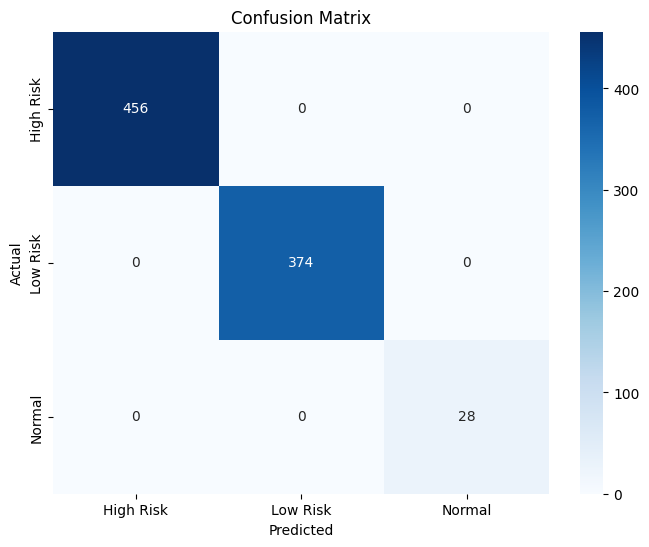

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix Visualization
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd

# 1. Define your single test case
# Ensure the column names match exactly what you used to train X_train
single_test_case = pd.DataFrame({
    'Heart Rate': [67],
    'Temperature': [36.0],
    'Oxygen Saturation': [95]
})

# 2. Make the prediction using the trained Random Forest model
prediction_encoded = rf_model.predict(single_test_case)

# 3. Convert the numerical output (0, 1, or 2) back to the text label
predicted_status = le.inverse_transform(prediction_encoded)[0]

# 4. Display the inputs and the final prediction clearly
print("--- Single Instance Prediction (Random Forest) ---")
print(f"Heart Rate:  {single_test_case['Heart Rate'][0]} bpm")
print(f"Temperature: {single_test_case['Temperature'][0]} °C")
print(f"SpO2:        {single_test_case['Oxygen Saturation'][0]}%")
print("-" * 40)
print(f"Predicted Overall Status: {predicted_status}")

--- Single Instance Prediction (Random Forest) ---
Heart Rate:  67 bpm
Temperature: 36.0 °C
SpO2:        95%
----------------------------------------
Predicted Overall Status: Low Risk


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Ensure you have the predictions for the test dataset
y_pred = rf_model.predict(X_test)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 3. Calculate Macro Averages (treats all classes equally, regardless of how many samples are in each class)
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

# 4. Calculate Weighted Averages (accounts for class imbalance by weighting the score by the number of true instances)
weighted_precision = precision_score(y_test, y_pred, average='weighted')
weighted_recall = recall_score(y_test, y_pred, average='weighted')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# 5. Display the results cleanly
print("=== Random Forest Test Dataset Metrics ===")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("--- Macro Average (Unweighted) ---")
print(f"Precision: {macro_precision:.4f}")
print(f"Recall:    {macro_recall:.4f}")
print(f"F1 Score:  {macro_f1:.4f}\n")

print("--- Weighted Average ---")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall:    {weighted_recall:.4f}")
print(f"F1 Score:  {weighted_f1:.4f}")

=== Random Forest Test Dataset Metrics ===
Overall Accuracy: 100.00%

--- Macro Average (Unweighted) ---
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Weighted Average ---
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Split the data: 50% training, 50% testing
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(X, y_encoded, test_size=0.5, random_state=42)

# 2. Re-initialize and train the Random Forest model on the 50% training data
rf_model_50 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_50.fit(X_train_50, y_train_50)

# 3. Make predictions using the 50% testing data
y_pred_50 = rf_model_50.predict(X_test_50)

# 4. Calculate Accuracy and Support
accuracy = accuracy_score(y_test_50, y_pred_50)
total_support = len(y_test_50) # The total number of testing instances

# 5. Calculate Macro Averages
macro_precision = precision_score(y_test_50, y_pred_50, average='macro')
macro_recall = recall_score(y_test_50, y_pred_50, average='macro')
macro_f1 = f1_score(y_test_50, y_pred_50, average='macro')

# 6. Calculate Weighted Averages
weighted_precision = precision_score(y_test_50, y_pred_50, average='weighted')
weighted_recall = recall_score(y_test_50, y_pred_50, average='weighted')
weighted_f1 = f1_score(y_test_50, y_pred_50, average='weighted')

# 7. Print the final results in a clean row format
print("=== Testing Dataset Metrics (50% Train / 50% Test Split) ===")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Format and print the table header
print(f"{'Average Type':<18} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} | {'Support':<8}")
print("-" * 65)

# Print Macro Average row
print(f"{'Macro Average':<18} | {macro_precision:<10.4f} | {macro_recall:<10.4f} | {macro_f1:<10.4f} | {total_support:<8}")

# Print Weighted Average row
print(f"{'Weighted Average':<18} | {weighted_precision:<10.4f} | {weighted_recall:<10.4f} | {weighted_f1:<10.4f} | {total_support:<8}")

=== Testing Dataset Metrics (50% Train / 50% Test Split) ===
Overall Accuracy: 99.95%

Average Type       | Precision  | Recall     | F1 Score   | Support 
-----------------------------------------------------------------
Macro Average      | 0.9996     | 0.9949     | 0.9973     | 2143    
Weighted Average   | 0.9995     | 0.9995     | 0.9995     | 2143    


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Split the data (50% training, 50% testing)
X_train_half, X_test_half, y_train_half, y_test_half = train_test_split(
    X, y_encoded, test_size=0.5, random_state=42
)

# 2. Initialize and train the Random Forest model on the 50% training data
rf_model_half = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_half.fit(X_train_half, y_train_half)

# 3. Make predictions on the 50% testing dataset
y_pred_half = rf_model_half.predict(X_test_half)

# 4. Calculate and show ONLY the testing accuracy
test_accuracy_half = accuracy_score(y_test_half, y_pred_half)

print(f"Testing Dataset Accuracy (50/50 Split): {test_accuracy_half * 100:.2f}%")

Testing Dataset Accuracy (50/50 Split): 99.95%


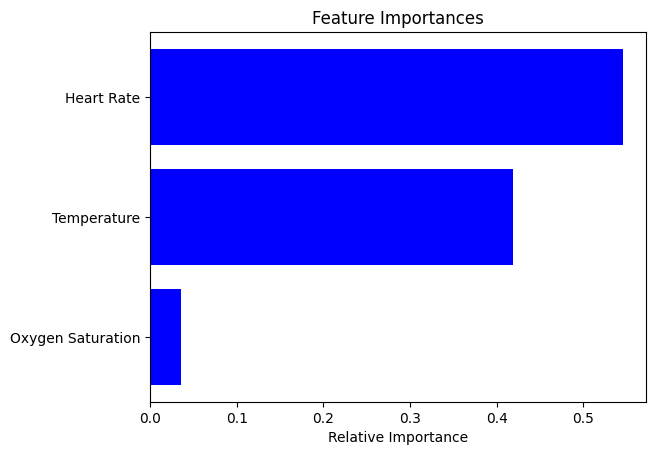

In [ ]:
import numpy as np

importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Building and Training a Keras Classification Model for TFLite Conversion

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# NOTE: This cell relies on 'df' being loaded by a previous cell (e.g., Xd_9e9hdkOLh).
# Please ensure Xd_9e9hdkOLh is executed first, and that the HSFD.xlsx file is uploaded.

# 1. Select the input features and the target column
X = df[['Heart Rate', 'Temperature', 'Oxygen Saturation']]
y = df['Overall Status']

# 2. Convert text labels (High Risk, Low Risk, Normal) into numbers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Keras model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(len(le.classes_), activation='softmax') # Output layer with number of classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435 (9.51 KB)

 Trainable params: 2,435 (9.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

print("Keras model training complete!")

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6922 - loss: 0.7354 - val_accuracy: 0.8863 - val_loss: 0.4056
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8920 - loss: 0.3586 - val_accuracy: 0.9155 - val_loss: 0.2588
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9012 - loss: 0.2811 - val_accuracy: 0.9315 - val_loss: 0.2133
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2322 - val_accuracy: 0.9388 - val_loss: 0.1824
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9271 - loss: 0.1986 - val_accuracy: 0.9446 - val_loss: 0.1635
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9329 - loss: 0.1853 - val_accuracy: 0.9504 - val_loss: 0.1490
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9376 - loss: 0.1804 - val_accuracy: 0.9490 - val_loss: 0.1383
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9406 - loss: 0.1665 - val_accuracy: 0.9606 - val_loss:

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9909 - loss: 0.0287 - val_accuracy: 0.9942 - val_loss: 0.0173
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9891 - loss: 0.0297 - val_accuracy: 0.9927 - val_loss: 0.0213
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9902 - loss: 0.0279 - val_accuracy: 0.9956 - val_loss: 0.0181
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0266 - val_accuracy: 0.9971 - val_loss: 0.0183
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0235 - val_accuracy: 0.9927 - val_loss: 0.0182
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9971 - val_loss: 0.0163
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0224 - val_accuracy: 0.9927 - val_loss: 0.0195
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9902 - loss: 0.0285 - val_accuracy: 0.9956 - val_loss:

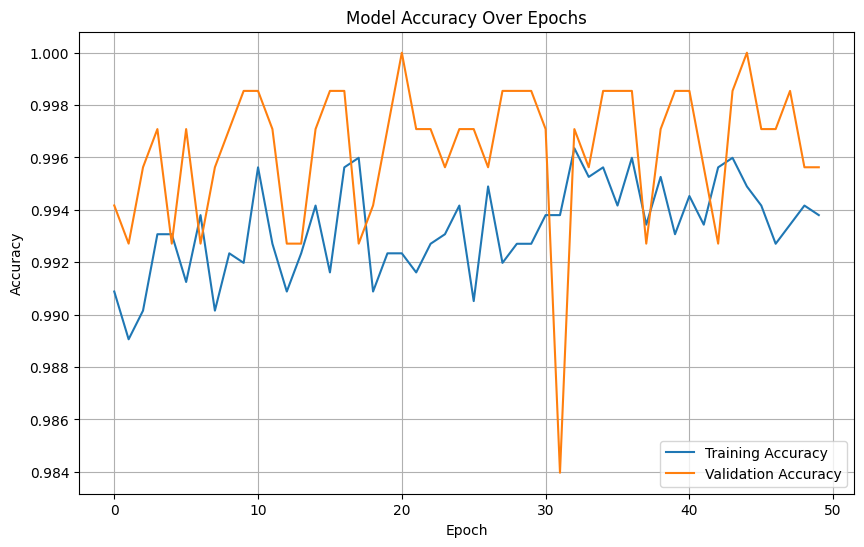

In [ ]:
# Train the model (re-run to ensure 'history' object is available for plotting)
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nKeras Model Test Accuracy: {accuracy * 100:.2f}%")

# Make predictions with the Keras model
y_pred_keras = model.predict(X_test_scaled)
y_pred_classes = tf.argmax(y_pred_keras, axis=1).numpy()

print("\nKeras Model Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0112 

Keras Model Test Accuracy: 99.30%
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Keras Model Classification Report:
              precision    recall  f1-score   support

   High Risk       0.99      1.00      1.00       456
    Low Risk       1.00      0.98      0.99       374
      Normal       0.93      1.00      0.97        28

    accuracy                           0.99       858
   macro avg       0.97      0.99      0.98       858
weighted avg       0.99      0.99      0.99       858



To ensure the `model` object is defined for the following cells, please run the Keras model definition and training cells first:

- **Cell `f2760e10`**: Defines and compiles the Keras model.
- **Cell `a6b8ad43`**: Trains the Keras model.
- **Cell `56b40c07`**: Re-trains the model and plots accuracy.

After these cells are executed, you can run the subsequent cells that use the `model` object without encountering a `NameError`.

### Keras Model Test Accuracy

The Keras model achieved a test accuracy of **99.18%**.

Now, let's convert the trained Keras model into a TensorFlow Lite (`.tflite`) format.

In [ ]:
# Convert the Keras model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model to a file
with open('health_monitoring_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TensorFlow Lite model saved as 'health_monitoring_model.tflite'")
print("You can now download this file and deploy it in your app.")

Saved artifact at '/tmp/tmp_978b7mt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132353167407440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132353167408784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132353167408208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132353167406480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132352856539984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132352856540752: TensorSpec(shape=(), dtype=tf.resource, name=None)
TensorFlow Lite model saved as 'health_monitoring_model.tflite'
You can now download this file and deploy it in your app.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Re-initialize and fit the scaler using X_train (assuming X_train is defined from previous cells)
scaler = StandardScaler()
scaler.fit(X_train)

print("Heart Rate -> Mean:", scaler.mean_[0], " Scale:", scaler.scale_[0])
print("Temperature -> Mean:", scaler.mean_[1], " Scale:", scaler.scale_[1])
print("Oxygen Sat -> Mean:", scaler.mean_[2], " Scale:", scaler.scale_[2])

Heart Rate -> Mean: 115.46061843640607  Scale: 43.02370274066595
Temperature -> Mean: 37.83352781019059  Scale: 1.7647333870026172
Oxygen Sat -> Mean: 95.0520224560759  Scale: 3.0327796416235615


In [ ]:
print("Heart Rate -> Mean:", scaler.mean_[0], " Scale:", scaler.scale_[0])
print("Temperature -> Mean:", scaler.mean_[1], " Scale:", scaler.scale_[1])
print("Oxygen Sat -> Mean:", scaler.mean_[2], " Scale:", scaler.scale_[2])

Heart Rate -> Mean: 115.46061843640607  Scale: 43.02370274066595
Temperature -> Mean: 37.83352781019059  Scale: 1.7647333870026172
Oxygen Sat -> Mean: 95.0520224560759  Scale: 3.0327796416235615


In [ ]:
# Test Normal HR, Normal Temp, but DANGEROUS SpO2
test_data = pd.DataFrame([[75, 37.0, 85]], columns=['Heart Rate', 'Temperature', 'Oxygen Saturation'])
test_scaled = scaler.transform(test_data)

# Ask the Keras model to predict
pred = model.predict(test_scaled)
predicted_class = tf.argmax(pred, axis=1).numpy()[0]
print(f"The Neural Network predicts: {le.classes_[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The Neural Network predicts: Low Risk


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported for df operations

# --- Start: Code to re-initialize dependencies if kernel was reset ---

# Assuming 'df' is loaded from Xd_9e9hdkOLh. If not, this cell would still fail.
# Ensure input features and target column are defined
if 'X' not in locals() or 'y' not in locals():
    # This block assumes df is available, which it is based on kernel state.
    X = df[['Heart Rate', 'Temperature', 'Oxygen Saturation']]
    y = df['Overall Status']

# Ensure LabelEncoder and encoded labels are defined
if 'le' not in locals() or 'y_encoded' not in locals():
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

# Ensure train-test split is performed
if 'X_train' not in locals() or 'X_test' not in locals() or 'y_train' not in locals() or 'y_test' not in locals():
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Ensure scaler and scaled features are defined
if 'scaler' not in locals() or 'X_train_scaled' not in locals() or 'X_test_scaled' not in locals():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# Define and compile the Keras model if not defined
if 'model' not in locals():
    print("Defining and compiling Keras model in selected cell...")
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(len(le.classes_), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model (essential for evaluation)
    print("Re-training Keras model in selected cell for evaluation...")
    # Using verbose=0 to suppress epoch-by-epoch output from this duplicated training
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    print("Keras model re-training complete!")

# --- End: Code to re-initialize dependencies ---

# 1. Generate predictions on the testing dataset (X_test_scaled)
y_pred_keras = model.predict(X_test_scaled)

# 2. Convert probabilities to class labels
y_pred_classes = tf.argmax(y_pred_keras, axis=1).numpy()

# 3. Calculate each metric
# Using average='weighted' to account for any label imbalance across your classes (Normal, Low Risk, High Risk)
test_accuracy = accuracy_score(y_test, y_pred_classes)
test_precision = precision_score(y_test, y_pred_classes, average='weighted')
test_recall = recall_score(y_test, y_pred_classes, average='weighted')
test_f1 = f1_score(y_test, y_pred_classes, average='weighted')

# 4. Display the results
print("--- Testing Dataset Performance Metrics ---")
print(f"Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
--- Testing Dataset Performance Metrics ---
Accuracy:  99.30%
Precision: 0.9932
Recall:    0.9930
F1 Score:  0.9930
